# ✈️ AI Travel Agent & Expense Planner

## 🎯 Purpose
An intelligent travel planning assistant that helps users plan trips to **any city worldwide** with **real-time data** and **detailed cost estimations.**

---

## 📝 Assignment Objectives
The AI Travel Agent & Expense Planner should:
- ✅ Retrieve **real-time weather information**
- ✅ Discover **top attractions and activities**
- ✅ Estimate **hotel costs** (per day × total days)
- ✅ Perform **currency conversion** to the user’s native currency
- ✅ Generate a **full itinerary**
- ✅ Calculate **total expenses**
- ✅ Provide a **summary of the entire trip**

---

## ⚙️ Workflow Overview

### 1. 🧍 User Input
User provides:
- Destination city
- Number of days
- Budget range
- Native currency

---

### 2. 📍 Search Attractions and Activities
- `search_attractions()`: Find popular tourist spots
- `search_restaurants()`: List recommended local restaurants
- `search_activities()`: Recommend city-specific activities
- `search_transportation()`: Suggest transport options within the city

---

### 3. 🌦️ Get Weather Forecast
- `get_current_weather(city)`: Fetch real-time weather
- `get_weather_forecast(city, days)`: Get forecast for the entire trip duration

---

### 4. 🏨 Search Hotels & Estimate Cost
- `search_hotels(city)`: Retrieve hotels based on location and budget
- `estimate_hotel_cost(rate_per_night, total_days)`: Calculate total accommodation cost
- `suggest_budget_range(user_budget)`: Validate or suggest budget range

---

### 5. 💰 Calculate Total Expense
- `calculate_total_cost(items: List[float])`: Add up all cost components
- `calculate_daily_budget(total_cost, days)`: Derive average daily spend

---

### 6. 💱 Currency Conversion
- `get_exchange_rate(from_currency, to_currency)`: Fetch real-time exchange rates
- `convert_currency(amount, rate)`: Convert expenses to user’s currency

---

### 7. 🗓️ Generate Itinerary
- `get_day_plan(day_number)`: Suggest day-wise plan
- `create_full_itinerary(num_days)`: Assemble full itinerary

---

### 8. 📋 Trip Summary
- `generate_summary(trip_data)`: Summarize trip details, costs, and itinerary

---

## 🔁 Final Output
The system should return the **complete travel plan**, including:
- Weather forecast
- Attractions and activities
- Hotel information
- Daily and total costs
- Itinerary
- Currency-adjusted expenses
- Summary of the entire trip

---

## 🧱 Suggested OOP Design (Recommended)
Design the system using **Object-Oriented Programming (OOP)** for better modularity and scalability.

### Recommended Classes:
- **TravelPlanner:** Core controller
- **WeatherService:** Handles weather-related operations
- **AttractionFinder:** Finds attractions, restaurants, and activities
- **HotelService:** Manages hotel searches and cost estimation
- **CurrencyConverter:** Converts between currencies
- **ItineraryBuilder:** Constructs the full itinerary
- **TripSummary:** Creates the final summary

> 💡 **Tip:**  
> Use `@tool` decorated methods inside each class for **LangGraph** tool support.

---

## ✅ Additional Notes
- Try to make the system **modular, scalable, and API-driven.**
- Ensure all user-facing outputs are **clear, concise, and well-structured.**


# Model define


In [48]:
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv()
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

In [49]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
weather_api = os.getenv("WEATHER_API")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [50]:
llm = ChatGroq(model="qwen/qwen3-32b")

## Weather tools

In [51]:
from langchain_core.tools import tool
import requests

@tool
def get_current_weather(city: str) -> str:
    """
    Fetches the current weather conditions for a given city.

    input: city (string)

    output: Current temperature, condition (e.g., "Sunny, 25°C")
    """
    url = f"http://api.weatherstack.com/current?access_key={weather_api}&query={city}"
    response = requests.get(url)
    return response.json()
    

### Testing


In [52]:
get_current_weather.invoke("Hyderabad")

{'request': {'type': 'City',
  'query': 'Hyderabad, India',
  'language': 'en',
  'unit': 'm'},
 'location': {'name': 'Hyderabad',
  'country': 'India',
  'region': 'Telangana',
  'lat': '17.375',
  'lon': '78.474',
  'timezone_id': 'Asia/Kolkata',
  'localtime': '2025-07-04 17:23',
  'localtime_epoch': 1751649780,
  'utc_offset': '5.50'},
 'current': {'observation_time': '11:53 AM',
  'temperature': 30,
  'weather_code': 143,
  'weather_icons': ['https://cdn.worldweatheronline.com/images/wsymbols01_png_64/wsymbol_0006_mist.png'],
  'weather_descriptions': ['Haze'],
  'astro': {'sunrise': '05:47 AM',
   'sunset': '06:55 PM',
   'moonrise': '01:29 PM',
   'moonset': '12:33 AM',
   'moon_phase': 'Waxing Gibbous',
   'moon_illumination': 61},
  'air_quality': {'co': '327.45',
   'no2': '2.22',
   'o3': '70',
   'so2': '3.515',
   'pm2_5': '9.25',
   'pm10': '19.98',
   'us-epa-index': '1',
   'gb-defra-index': '1'},
  'wind_speed': 29,
  'wind_degree': 254,
  'wind_dir': 'WSW',
  'pressur

## Weather forecast tools


In [114]:
@tool
def get_weather_forecast(city: str, days: int = 5) -> str:
    """
    Fetches weather forecast for a given city.

    input: city (string), days (int, default 5)
    output: Weather forecast for next few days
    """
    try:
        # Get city coordinates
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
        geo_response = requests.get(geo_url)
        geo_data = geo_response.json()
        
        if not geo_data.get('results'):
            return f"Error: Could not find {city}"
        
        lat = geo_data['results'][0]['latitude']
        lon = geo_data['results'][0]['longitude']
        
        # Get forecast (free, no API key)
        forecast_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=temperature_2m_max,temperature_2m_min,weather_code&forecast_days={days}"
        response = requests.get(forecast_url)
        data = response.json()
        
        forecast_text = f"Weather forecast for {city}:\n"
        
        conditions = {
            0: "Clear", 1: "Mostly clear", 2: "Partly cloudy", 3: "Overcast",
            45: "Foggy", 51: "Light drizzle", 61: "Light rain", 63: "Rain", 
            71: "Light snow", 95: "Thunderstorm"
        }
        
        for i in range(len(data['daily']['time'])):
            date = data['daily']['time'][i]
            max_temp = data['daily']['temperature_2m_max'][i]
            min_temp = data['daily']['temperature_2m_min'][i]
            code = data['daily']['weather_code'][i]
            condition = conditions.get(code, "Unknown")
            
            forecast_text += f"{date}: {condition}, High {max_temp}°C, Low {min_temp}°C\n"
        
        return forecast_text
        
    except Exception as e:
        return f"Error: {str(e)}"



In [112]:
# import requests
# from datetime import datetime, timedelta
# @tool
# def get_weather_forecast(city: str, start_date: str, days: int = 5) -> str:
#     """
#     Fetches weather forecast for a given city starting from a specific date.

#     input: 
#         city (string)
#         start_date (string in 'YYYY-MM-DD' format)
#         days (int, default 5)
#     output:
#         Weather forecast for the specified date range
#     """
#     try:
#         # Validate start_date format
#         datetime.strptime(start_date, "%Y-%m-%d")
        
#         # Get city coordinates
#         geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
#         geo_response = requests.get(geo_url)
#         geo_data = geo_response.json()
        
#         if not geo_data.get('results'):
#             return f"Error: Could not find {city}"
        
#         lat = geo_data['results'][0]['latitude']
#         lon = geo_data['results'][0]['longitude']
        
#         # Calculate end_date
#         end_date = (datetime.strptime(start_date, "%Y-%m-%d") + timedelta(days=days - 1)).strftime("%Y-%m-%d")
        
#         # Get forecast
#         forecast_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_max,temperature_2m_min,weather_code&timezone=auto"
#         response = requests.get(forecast_url)
#         data = response.json()
        
#         forecast_text = f"Weather forecast for {city} from {start_date} to {end_date}:\n"
        
#         conditions = {
#             0: "Clear", 1: "Mostly clear", 2: "Partly cloudy", 3: "Overcast",
#             45: "Foggy", 51: "Light drizzle", 61: "Light rain", 63: "Rain", 
#             71: "Light snow", 95: "Thunderstorm"
#         }
#         display(data)
#         for i in range(len(data['daily']['time'])):
#             date = data['daily']['time'][i]
#             max_temp = data['daily']['temperature_2m_max'][i]
#             min_temp = data['daily']['temperature_2m_min'][i]
#             code = data['daily']['weather_code'][i]
#             condition = conditions.get(code, "Unknown")
            
#             forecast_text += f"{date}: {condition}, High {max_temp}°C, Low {min_temp}°C\n"
        
#         return forecast_text
        
#     except Exception as e:
#         return f"Error: {str(e)}"


### Testing

In [115]:
# forecast = get_weather_forecast.invoke({
#     "city":"Paris",
#     "start_date": "2025-08-01",
#      "days":4
#      })
# print(forecast)


In [116]:
response = get_weather_forecast.invoke(
    {
        "city": "Hyderabad,India",
        "days": 5,
        
    }
)
response

'Weather forecast for Hyderabad,India:\n2025-07-04: Thunderstorm, High 29.0°C, Low 23.4°C\n2025-07-05: Unknown, High 28.5°C, Low 23.2°C\n2025-07-06: Overcast, High 29.5°C, Low 23.2°C\n2025-07-07: Overcast, High 30.9°C, Low 23.1°C\n2025-07-08: Unknown, High 30.6°C, Low 23.1°C\n'

## Search Hotel Tools

In [55]:
load_dotenv()
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

In [56]:
from langchain_community.utilities import GoogleSerperAPIWrapper

search = GoogleSerperAPIWrapper()

search.run("best hotels in Hyderabad,KPHB under 5000 Rupees")

"Popular Hotels Rs 4001 To Rs 5000 in Kphb Colony, Hyderabad ; Hotel Ravila Grand Luxury Rooms. 4.71.2k Ratings. NH65 Mumbai Haiway Madinaguda - 6.18 km ; Ksr Inn. Name, Viswanadhunis Antilia Comfort Stay Inns · Swagath Paradise Guest Rooms ; Address, MIG II 41, Kphb Phase 9, KPHB Colony, Hyderabad - 500085 (GHMC Women\\'s ... Get Amazing deals on Budget Hotels in Kukatpally, Hyderabad.✓ Use coupon code & Get Upto 70% OFF instantly on Kukatpally, Hyderabad Hotels. Missing: KPHB Rupees 1. The Park Hyderabad · 2. Celebrity Resort · 3. Katriya Hotel & Towers · 4. The Golkonda Hotel · 5. Best Western Ashoka · 6. The Manohar ... Anupama Guest House. Location - Srinagar Colony Road, Jubilee Hills. Contact number - 040 2354 1207. ; Shree Shyam Nivas. Location: M.G. Road, ... Yes, Kukatpally has several affordable options like HOTEL SITARA GRAND KUKATPALLY, Lemonridge Hotels KPHB, FabExpress D Grand - Nr JNTU College Metro Station, ... Indira Nagar would be best provide your budget is on highe

In [57]:
@tool
def search_hotels(city: str, budget: int) -> str:
    """search hotel in the city under the user budget
    Args:
        city: str (which city user want to travel)
        budget: int (how much money user want to pay for hotel)
    
    output: it will provide some hotel name and cost such as day or week or the hotel policy wise.
    
    
    """
    search = GoogleSerperAPIWrapper()
    
    query = f"best hotel in {city} under ${budget}"
    
    response = search.run(query)
    return response





### Testing

In [58]:
search_hotels.invoke(
    {
        "city": "Hyderabad",
        "budget": 1500
    }
)
    

"Popular Guest House Rs 1001 To Rs 1500 in Hyderabad · Horizon Residency · Cosy Banjara · Brundavan Homes · Hotel Maruthi Residency Inn · Sucasa Homes · Ssv ... Cheap Hotels in Hyderabad · 1. Red Fox by Lemon Tree Hotels, Hyderabad · 2. Aditya Hometel · 3. Aditya Park, Hyderabad · 4. Green Park ... Taj Falaknuma Palace, Hyderabad. Best Hyderabad Hotels. The Park Hyderabad · Hotel Imperial Classic · Radisson Hyderabad Hitec City · THE CENT · Hotel Saptagiri ... Get Amazing deals on Budget Hotels in Hyderabad.✓ Use coupon code & Get Upto 70% OFF instantly on Hyderabad Hotels.Cheap hotels in Hyderabad with tariff, ... Book Top Hotels in Hyderabad ; The Manohar Hyderabad · 4.0 / 5. 1696 reviews ; Ellaa Hotel Gachibowli · 4.5 / 5. 1171 reviews ; Istay Hotel Hitec · 4.5 / 5. Hotels under 1000 in Madhapur, Hyderabad ; 4.1 · (96 Ratings). Platinum Nest | Rooms & Wi-Fi. Madhapur | 2.3 km drive to Mindspace IT Park, Hyderabad. Room in a ... The Golkonda Hotel · 5,198 · The Golkonda Hotel in Hyde

In [59]:
from langchain_core.tools import tool
from pydantic import BaseModel, Field


@tool
def estimate_hotel_cost(price_per_night: float, total_days: int) -> float:
    """Estimate total hotel cost based on price per night and number of days.
    
    price_per_night: float (description="Price per night of the selected hotel in USD")
    total_days: int (description="Total number of days the user will stay")
    
    """
    try:
        return round(price_per_night * total_days, 2)
    except Exception as e:
        return str(e)


In [60]:
estimate_hotel_cost.invoke({
    "price_per_night": 85.0,
    "total_days": 4
})

340.0

## Search attraction


In [61]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from pydantic import BaseModel, Field
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [62]:
@tool
def search_attractions(city: str) -> str:
    """
    Search top tourist attractions in a given city.

    Args:
        city (str): Name of the city to search for tourist attractions.

    Returns:
        str: A list of top tourist attractions or places of interest.
    """
    tavily = TavilySearch(max_results=5)
    return tavily.invoke(f"top tourist attractions in {city}")


### Testing

In [63]:
search_attractions("Hyderabad")


{'query': 'top tourist attractions in Hyderabad',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': '25 Places to Visit in Hyderabad in 2025 | Top Tourist Attractions & Places',
   'url': 'https://www.makemytrip.com/tripideas/places-to-visit-in-hyderabad',
   'content': 'Places To Visit In Hyderabad Places to Visit in Hyderabad Best Places to Visit in Hyderabad Tourist Places in HyderabadHussain Sagar Lake, Chowmahalla Palace, Qutb Shahi Tombs, Charminar, Nehru Zoological ParkStateTelanganaBest Time to Visit in HyderabadOctober to MarchThings to Do in HyderabadMoula Ali Dargah, Golconda Fort Near Hyderabad, Salar Jung Museum, Experience a Qawwalli at Dargah Yousufain Sharifain, Shop till You Drop at Laad BazaarPlaces to visit in Hyderabad with FamilyHave a Fabulous Day-Out at Ramoji Film City, Enjoy Cultural Evenings at Lamakaan, Spot Wildlife at KBR National Park, Relish Authentic Hyderabadi Biryani, Taj Falaknuma Our recommendation of the best place

In [64]:
@tool
def search_restaurants(city: str) -> str:
    """
    Search the best restaurants in a given city.

    Args:
        city (str): Name of the city to search for restaurants.

    Returns:
        str: A list of popular restaurants to try.
    """
    tavily = TavilySearch(max_results=5)
    return tavily.run(f"best restaurants to try in {city}")


@tool
def search_activities(city: str) -> str:
    """
    Search top activities or things to do in a city.

    Args:
        city (str): Name of the city to search for fun activities.

    Returns:
        str: A list of popular activities or experiences in the city.
    """
    tavily = TavilySearch(max_results=5)
    return tavily.run(f"fun activities to do in {city}")

@tool
def search_transportation(city: str) -> str:
    """
    Search transportation options in a city.

    Args:
        city (str): Name of the city to search for transport details.

    Returns:
        str: Transportation options like bus, metro, taxi, and car rental.
    """
    # serper = GoogleSerperAPIWrapper()
    # return serper.run(f"transportation options in {city} for tourists")
    
    tavily = TavilySearch(max_results=5)
    return tavily.run(f"list of transportation options in {city} for tourists")




In [65]:
search_transportation("Hyderebad,India")

{'query': 'list of transportation options in Hyderebad,India for tourists',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Transportation in Hyderabad, By Bus,Taxi, Car, Train, Local ...',
   'url': 'https://www.yatra.com/india-tourism/hyderabad/transport',
   'content': 'Transportation in Hyderabad- Local Transportation in Hyderabad is easily available to reach every part of Hyderabad. You can explore different modes of local/public transportation like Car, Train, Bus, Taxi, Cab within Hyderabad',
   'score': 0.80126834,
   'raw_content': None},
  {'title': 'Transportation in Hyderabad, India - ArcGIS StoryMaps',
   'url': 'https://storymaps.arcgis.com/stories/0cad3bb2b7c242bdab225b28b4941658',
   'content': "Hyderabad's Transportation Methods Hyderabad houses various kinds of private and public transportation that gets the locals to work, school, shopping complexes, eateries, and etc. With the variety of options locals and tourists have to get a

In [66]:
search_activities("Hyderebad,India")

{'query': 'fun activities to do in Hyderebad,India',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': '15 Best Fun Activities In Hyderabad That You May Not Have Yet Visited',
   'url': 'https://locknescape.com/fun-activities-places-hyderabad/',
   'content': "To bring out the kid in you and indulge in some serious 'fun', head out straight to the Sky Zone, one of the best fun places in Hyderabad for adults. A franchisee, having outlets in most cities in India, Sky Zone has tonnes of offerings for every age group. An indoor game in Hyderabad, the trampoline park, it has attractions like dodgeball, freestyle jump, sky ladder, and sky slam among",
   'score': 0.8967681,
   'raw_content': None},
  {'title': '25 Best & Fun Things To Do In Hyderabad (India)',
   'url': 'https://thetouristchecklist.com/things-to-do-in-hyderabad-india/',
   'content': "Hyderabad's mix of tradition and modernity makes it a unique and exciting place to visit. Looking for what t

## Calculate total cost tools


In [67]:
from langchain_core.tools import tool

@tool
def add(a: float, b: float) -> float:
    """
    Add two numbers.

    Args:
        a (float): First number.
        b (float): Second number.

    Returns:
        float: The sum of a and b.
    """
    return round(a + b, 2)


@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers.

    Args:
        a (float): First number.
        b (float): Second number.

    Returns:
        float: The product of a and b.
    """
    return round(a * b, 2)


@tool
def calculate_total_cost(hotel_cost: float, activity_cost: float, transport_cost: float) -> float:
    """
    Calculate the total cost of the trip.

    Args:
        hotel_cost (float): Total hotel cost.
        activity_cost (float): Total activity/entertainment cost.
        transport_cost (float): Total transportation cost.

    Returns:
        float: Combined total trip cost.
    """
    return round(hotel_cost + activity_cost + transport_cost, 2)


@tool
def calculate_daily_budget(total_cost: float, days: int) -> float:
    """
    Calculate daily budget based on total cost and number of days.

    Args:
        total_cost (float): Total expense for the trip.
        days (int): Total number of travel days.

    Returns:
        float: Estimated daily budget.
    """
    if days <= 0:
        raise ValueError("Days must be greater than zero.")
    return round(total_cost / days, 2)

## Currency conversion Factor


In [68]:
import requests
from langchain_core.tools import tool
load_dotenv()

EXCHANGE_API_KEY = os.getenv("EXCHANGE_RATE_API")

@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
    """
    Fetch the currency conversion rate between two currencies.

    Args:
        base_currency (str): The code of the base currency (e.g., 'USD').
        target_currency (str): The code of the currency to convert to (e.g., 'BDT').

    Returns:
        float: The conversion rate from base_currency to target_currency.
    """
    url = f"https://v6.exchangerate-api.com/v6/{EXCHANGE_API_KEY}/pair/{base_currency}/{target_currency}"
    response = requests.get(url)
    data = response.json()
    
    if response.status_code == 200 and data.get("conversion_rate"):
        return float(data["conversion_rate"])
    else:
        raise ValueError(f"Failed to get conversion rate: {data}")

In [69]:
get_conversion_factor(
    {
        "base_currency": "USD",
        "target_currency": "INR"
    }
)

85.4393

## conversion factor


In [70]:
@tool
def convert_currency(amount: float, conversion_rate: float) -> float:
    """
    Convert an amount from base currency to target currency using a conversion rate.

    Args:
        amount (float): Amount in base currency.
        conversion_rate (float): Conversion rate to target currency.

    Returns:
        float: Amount in target currency.
    """
    return round(amount * conversion_rate, 2)

## Itinery genration tools


In [71]:
from langchain_core.tools import tool

@tool
def get_day_plan(city: str, interests: str = "sightseeing, local food, culture") -> str:
    """
    Generate a one-day itinerary for a city based on user interests.

    Args:
        city (str): Name of the city to plan for.
        interests (str): Interests like sightseeing, food, culture.

    Returns:
        str: A detailed one-day plan with times, locations, and activities.
    """
    return (
        f"You are planning a 1-day trip in {city}. "
        f"Generate a time-based schedule from 9:00 AM to 9:00 PM, including {interests}. "
        f"Include breakfast, lunch, dinner, 3-5 key attractions, and time for rest/shopping."
    )


@tool
def create_full_itinerary(city: str, days: int, interests: str = "sightseeing, food") -> str:
    """
    Generate a full multi-day itinerary for a city.

    Args:
        city (str): Destination city.
        days (int): Number of days for the trip.
        interests (str): User interests.

    Returns:
        str: A complete day-wise itinerary.
    """
    return (
        f"Create a {days}-day itinerary for {city}, including activities based on {interests}. "
        f"Each day should include breakfast, lunch, dinner, 3–4 attractions, and cultural or relaxing activities. "
        f"Keep plans balanced and avoid repeating the same spots."
    )

## Create the trip summary


In [72]:
from langchain_core.tools import tool

@tool
def create_trip_summary(city: str, days: int, total_cost: float, currency: str = "USD") -> str:
    """
    Generates a high-level trip summary for the user.

    Args:
        city (str): Destination city for the trip.
        days (int): Number of days planned for the trip.
        total_cost (float): Total estimated cost of the trip in the specified currency.
        currency (str): Currency code, e.g., USD, EUR, BDT.

    Returns:
        str: Prompt instruction for the LLM to summarize the trip.
    """
    return (
        f"Generate a short and friendly trip summary for a {days}-day trip to {city}. "
        f"The estimated total cost is {total_cost:.2f} {currency}. "
        f"Include the number of days, cost estimate, and encourage the traveler. "
        f"End with a line like: 'Have a wonderful trip to {city}!'"
    )

## Complete trip plan


In [73]:
from langchain_core.tools import tool

@tool
def return_complete_travel_plan(city: str, days: int) -> str:
    """
    Returns a final instruction to the LLM to compile all parts of the trip into a single, complete plan.

    Args:
        city (str): Destination city.
        days (int): Duration of the trip in days.

    Returns:
        str: Prompt to compile all previous data into a final travel plan output.
    """
    return (
        f"Assemble a complete travel plan for a {days}-day trip to {city}. "
        f"Include these sections in order:\n"
        f"1. 🌍 Destination and Duration\n"
        f"2. 🌤️ Weather Forecast Summary\n"
        f"3. 🏙️ Top Attractions\n"
        f"4. 🍽️ Recommended Restaurants\n"
        f"5. 🚗 Transportation Tips\n"
        f"6. 🛏️ Hotel Info and Estimated Cost\n"
        f"7. 📅 Full Day-wise Itinerary\n"
        f"8. 💰 Total Trip Expense and Currency Conversion\n"
        f"9. ✨ Final Trip Summary\n\n"
        f"Ensure everything is well-formatted, friendly, and easy to follow."
    )

# Build 

In [74]:
SYSTEM_PROMPT = """

You are an AI Travel Planner and Expense Manager. Your task is to assist users in planning trips to any city worldwide using reasoning and tools.

You follow the **ReAct pattern**:
1. Think about what the user needs.
2. Decide which tool to use and why.
3. Call the tool using the correct arguments.
4. Observe the result.
5. Repeat reasoning and tool usage as needed.
6. Finally, return a complete, friendly, and well-organized travel plan.

You have access to the following tools:

1. `search_attractions(city: str)` - Find top tourist attractions in the city.
2. `search_restaurants(city: str)` - Find popular places to eat.
3. `search_activities(city: str)` - Find fun or cultural activities in the city.
4. `search_transportation(city: str)` - Get information about transport options.
5. `get_current_weather(city: str)` - Check the current weather.
6. `get_weather_forecast(city: str)` - Get the weather forecast for upcoming days.
7. `search_hotels(city: str, budget: int)` - Search for hotels within a user’s budget.
8. `estimate_hotel_cost(cost_per_day: float, total_days: int)` - Estimate total hotel cost.
9. `add(a: float, b: float)` - Add two values.
10. `multiply(a: float, b: float)` - Multiply two values.
11. `calculate_total_cost(hotel_cost: float, misc_cost: float)` - Add up all costs.
12. `calculate_daily_budget(total_cost: float, days: int)` - Estimate daily budget.
13. `get_conversion_factor(base_currency: str, target_currency: str)` - Get exchange rate.
14. `convert(base_currency: float, conversion_rate: float)` - Convert between currencies.
15. `create_itinerary_prompt(city: str, days: int)` - Generate a full day-wise itinerary.
16. `create_trip_summary(city: str, days: int, total_cost: float, currency: str)` - Generate a brief trip summary.
17. `return_complete_travel_plan(city: str, days: int)` - Compile and return a complete travel plan.

Be thoughtful and structured. Use tools only when required. Wait for tool results before deciding the next step.

If the user provides a destination and number of days, start by gathering key information like attractions, weather, and hotels. Calculate costs, convert currency, generate an itinerary, and end with a trip summary.

Your final response must be complete and organized, using markdown formatting (headers, bullet points) for easy reading. You should never hallucinate data — always use tools to get real-time or accurate info.

Let's get started.


"""

In [75]:
tools = [get_current_weather, get_weather_forecast, search_hotels, estimate_hotel_cost, search_attractions, search_restaurants, search_activities, search_transportation, add, multiply, calculate_total_cost, calculate_daily_budget, get_conversion_factor, convert_currency, get_day_plan, create_full_itinerary, create_trip_summary, return_complete_travel_plan]
llm_with_tools = llm.bind_tools(tools)


In [76]:
llm_with_tools.invoke(
    "Hi, I want to take a 5-day trip to Bangkok next month. My hotel budget is around 2000 Rupess per night. I’d like to know what the weather will be like, what places I can visit, and how much the whole trip might cost. I’ll be paying in Baht , but my native currency is Rupees. Also, I prefer local food and public transportation. Can you plan it all for me?"
)

AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's tackle this user's request step by step. First, they want a 5-day trip to Bangkok with a hotel budget of 2000 Rupees per night. They need weather info, places to visit, total cost in Baht (they pay in Baht but their native currency is Rupees), and they prefer local food and public transport. Let me outline the functions I need to use.\n\n1. **Weather Forecast**: They mentioned wanting to know the weather. The `get_weather_forecast` function can provide a 5-day forecast for Bangkok. The city is required, and days default to 5, which matches their trip duration.\n\n2. **Hotels**: They have a budget of 2000 Rupees per night. The `search_hotels` function needs the city (Bangkok) and budget. But wait, the budget is in Rupees, but the cost might be in Baht. Maybe I need to handle currency conversion later. For now, just pass the budget as given.\n\n3. **Attractions and Restaurants**: They want places to visit and loca

In [79]:
from langgraph.graph import END, MessagesState
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition


In [80]:
def call_model(state: MessagesState):
    question = state["messages"]
    
    question_with_system_prompt = [SYSTEM_PROMPT] + question
    
    response = llm_with_tools.invoke(question_with_system_prompt)
    
    return {
        "messages": [response]
    }

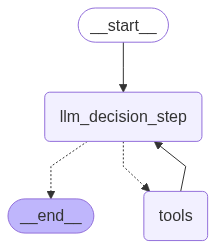

In [81]:
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(MessagesState) 

builder.add_node("llm_decision_step", call_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_decision_step")
builder.add_conditional_edges(
    "llm_decision_step",
    ## if last messages is tools call then call the tools
    ## if last messages is not tools call return end
    tools_condition
)
builder.add_edge("tools", "llm_decision_step")

react_agent = builder.compile()

from IPython.display import display, Image

display(Image(react_agent.get_graph().draw_mermaid_png()))

In [91]:
input = "Hi, I want to take a 5-day trip to Bangkok and Pattaya next month(Augest-2025 first week). My hotel budget is around 2000 Rupess per night. I’d like to know what the weather will be like, what places I can visit, and how much the whole trip might cost. I’ll be paying in Baht , but my native currency is Rupees. Also, I prefer local food (Indian Style) and public transportation. Can you plan it all for me?"

In [92]:
output = react_agent.invoke(
    {
        "messages": [input]
    }
)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi, I want to take a 5-day trip to Bangkok and Pattaya next month(Augest-2025 first week). My hotel budget is around 2000 Rupess per night. I’d like to know what the weather will be like, what places I can visit, and how much the whole trip might cost. I’ll be paying in Baht , but my native currency is Rupees. Also, I prefer local food (Indian Style) and public transportation. Can you plan it all for me?
================================== Ai Message ==================================
Tool Calls:
  get_weather_forecast (yspzw6jqs)
 Call ID: yspzw6jqs
  Args:
    city: Bangkok
    days: 5
================================= Tool Message =================================
Name: get_weather_forecast

Weather forecast for Bangkok:
2025-07-04: Unknown, High 33.5°C, Low 25.3°C
2025-07-05: Thunderstorm, High 34.0°C, Low 25.7°C
2025-07-06: Unknown, High 32.7°C, Low 25.9°C
2025-07-07: Unknown, High 32.3°C, Low 26.3°C


In [93]:
from IPython.display import Markdown

Markdown(output["messages"][-1].content)

### **Travel Plan for 5-Day Trip to Bangkok & Pattaya (August 2025)**  
**Budget:** 2000 INR/night (≈759 THB) | **Currency Conversion:** 1 INR = 0.3795 THB  

---

### **1. Weather Forecast**  
**Bangkok (First 3 Days):**  
- Hot and humid (32–34°C), with a thunderstorm on Day 2.  
- **Tip:** Carry an umbrella and light clothing.  

**Pattaya (Next 2 Days):**  
- Cooler and overcast (29°C), ideal for beach activities.  

---

### **2. Accommodation**  
**Bangkok (3 Nights):**  
- **Recommended Hotels:**  
  - Zircon Hotel (3-star, ~15 USD/night ≈ 525 THB)  
  - Ambassador Hotel Bangkok (~25 USD/night ≈ 875 THB)  
- **Total Cost:** ~1,584 THB (within budget).  

**Pattaya (2 Nights):**  
- **Recommended Hotels:**  
  - Grand Bella Hotel (4-star, ~9 USD/night ≈ 311 THB)  
  - At Sea Residence (~12 USD/night ≈ 419 THB)  
- **Total Cost:** ~1,030 THB.  

---

### **3. Daily Itinerary**  
#### **Bangkok (Days 1–3)**  
**Day 1:**  
- **Morning:** Wat Phra Kaew (Temple of the Emerald Buddha).  
- **Afternoon:** Grand Palace and Wat Pho.  
- **Evening:** Food tour at Yaowarat Market (Indian-style curries).  

**Day 2:**  
- **Morning:** Angthong National Marine Park (boat trip).  
- **Afternoon:** Chatuchak Market shopping.  
- **Evening:** Skytrain to Sukhumvit for street food.  

**Day 3:**  
- **Morning:** Wat Arun (Temple of Dawn).  
- **Afternoon:** Train to Pattaya (≈600 THB round trip).  
- **Evening:** Dinner at Indian restaurant in Pattaya.  

#### **Pattaya (Days 4–5)**  
**Day 4:**  
- **Morning:** Sanctuary of Truth (wooden temple).  
- **Afternoon:** Walking Street (local nightlife).  
- **Evening:** Beachside seafood dinner.  

**Day 5:**  
- **Morning:** Nong Nooch Tropical Botanical Garden.  
- **Afternoon:** Return to Bangkok via train.  

---

### **4. Budget Breakdown**  
| **Category**         | **Cost (THB)** | **Cost (INR)** |  
|----------------------|----------------|----------------|  
| **Hotels**           | 2,614          | 7,000          |  
| **Transport**        | 600 (Bangkok-Pattaya train) | 1,650        |  
| **Food**             | 7,500 (local Indian restaurants) | 20,000 |  
| **Attractions**      | 1,500 (entrance fees) | 4,000        |  
| **Total**            | **12,214 THB** | **~32,650 INR** |  

---

### **5. Travel Tips**  
- **Transport:** Use BTS Skytrain/MRT in Bangkok and public buses in Pattaya.  
- **Currency:** Carry THB for ease, but convert INR using ATMs (1 THB ≈ 2.63 INR).  
- **Packing:** Light clothing, sunscreen, and a raincoat for Bangkok’s heat and storms.  

---

### **6. Final Summary**  
**Trip Summary:**  
- **Cities:** Bangkok (3 days), Pattaya (2 days).  
- **Total Cost:** ~12,214 THB (≈32,650 INR).  
- **Highlights:** Temples, beaches, street food, and cultural experiences.  

Let me know if you’d like adjustments to the plan! 🌴